<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning & Deep Learning</b></center>

<center><b><h1>Lab - 6</b></center>    
<pre>    

# SVR

# Importing the libraries

In [1]:
import numpy as np
import pandas as pd

# Read World bank CSV

In [22]:
df=pd.read_csv('WorldBank.csv')

In [23]:
df.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,714.748450,700.408454,742.928128,761.441742,632.269428,624.224980,706.102795,766.360840,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614,5.246771,5.729495,5.060904,4.706801,4.471147,3.760466,3.921611,3.438072,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.48805,10.124611,9.45137,10.52948,10.891125,...,0.755066,0.273842,0.440954,1.514439,2.228351,2.270593,1.770314,0.535419,NaN,NaN


# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [24]:
data=df[df['Indicator Name']=='Population ages 15-64 (% of total population)']
data.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


In [25]:
india=data[data['Country Name']=='India']
india

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [26]:
X=india.columns[4:].astype(int).values.reshape(-1,1)

In [27]:
X

array([[1960],
       [1961],
       [1962],
       [1963],
       [1964],
       [1965],
       [1966],
       [1967],
       [1968],
       [1969],
       [1970],
       [1971],
       [1972],
       [1973],
       [1974],
       [1975],
       [1976],
       [1977],
       [1978],
       [1979],
       [1980],
       [1981],
       [1982],
       [1983],
       [1984],
       [1985],
       [1986],
       [1987],
       [1988],
       [1989],
       [1990],
       [1991],
       [1992],
       [1993],
       [1994],
       [1995],
       [1996],
       [1997],
       [1998],
       [1999],
       [2000],
       [2001],
       [2002],
       [2003],
       [2004],
       [2005],
       [2006],
       [2007],
       [2008],
       [2009],
       [2010],
       [2011],
       [2012],
       [2013],
       [2014],
       [2015],
       [2016],
       [2017],
       [2018],
       [2019],
       [2020]])

In [28]:
y=india.iloc[0,4:].astype(float).values.reshape(-1,1)

In [29]:
print(y)

[[56.49748004]
 [56.17753236]
 [55.80745463]
 [55.46166361]
 [55.24893881]
 [55.21135053]
 [55.09090078]
 [55.15534672]
 [55.34507283]
 [55.57014408]
 [55.78194745]
 [55.85676846]
 [55.95268174]
 [56.07247186]
 [56.23447551]
 [56.44405309]
 [56.49722595]
 [56.62068516]
 [56.78900152]
 [56.9691436 ]
 [57.1425581 ]
 [57.18105454]
 [57.22630775]
 [57.28875038]
 [57.39054366]
 [57.54142108]
 [57.55350984]
 [57.6545119 ]
 [57.81875323]
 [58.01501187]
 [58.22990246]
 [58.37403848]
 [58.5472698 ]
 [58.75605047]
 [59.012126  ]
 [59.31657719]
 [59.56507329]
 [59.8572303 ]
 [60.18600058]
 [60.53971518]
 [60.90862046]
 [61.18898716]
 [61.4993847 ]
 [61.83084479]
 [62.173897  ]
 [62.52276485]
 [62.80842981]
 [63.10261029]
 [63.40924784]
 [63.74196691]
 [64.10821053]
 [64.429404  ]
 [64.80551944]
 [65.20848906]
 [65.5959799 ]
 [65.94416405]
 [66.27426247]
 [66.53818711]
 [66.7667425 ]
 [67.00381119]
 [        nan]]


# Plot scatter plot of Population ages 15-64 (% of total population)

In [30]:
import matplotlib.pyplot as plt

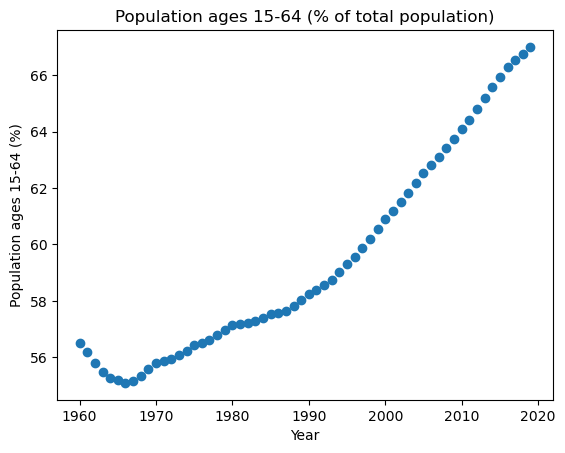

In [31]:
plt.scatter(X,y)
plt.xlabel("Year")
plt.ylabel("Population ages 15-64 (%)")
plt.title("Population ages 15-64 (% of total population)")
plt.show()

# Splitting the dataset into the Training set and Test set

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

# Feature Scaling (Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [33]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_y = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

y_train = sc_y.fit_transform(
    y_train.reshape(-1,1)
)

# Fitting SVR on 3 Different Kernel on dataset

In [34]:
from sklearn.svm import SVR

In [35]:
svr_linear=SVR(kernel='linear')
svr_linear.fit(X_train,y_train.ravel())

SVR(kernel='linear')

In [36]:
svr_poly=SVR(kernel='poly',degree=3)
svr_poly.fit(X_train,y_train.ravel())

SVR(kernel='poly')

In [37]:
svr_rbf=SVR(kernel='rbf')
svr_rbf.fit(X_train,y_train.ravel())

SVR()

# Predict the x_test using 3 Kernel

In [41]:
y_pred_linear=svr_linear.predict(X_test)
y_pred_linear

array([-0.27399717,  0.22876426,  1.62532378, -0.1622724 , -1.11193288,
       -1.61469431,  0.17290188,  1.5694614 ,  0.50807617, -0.49744669,
       -1.50296954, -1.16779526, -0.05054764])

In [42]:
y_pred_poly=svr_poly.predict(X_test)
y_pred_poly

array([ 0.03427012,  0.05320915,  2.67981673,  0.04256399, -0.73729943,
       -2.38378147,  0.04845916,  2.41990395,  0.13045573, -0.02169115,
       -1.90923029, -0.86312691,  0.04437342])

In [43]:
y_pred_rbf=svr_rbf.predict(X_test)
y_pred_rbf

array([-0.50197228, -0.05075943,  1.78036966, -0.41330682, -1.09967206,
       -1.04105508, -0.11123049,  1.78181772,  0.31704059, -0.678068  ,
       -1.10027412, -1.11864886, -0.32103327])

In [44]:
svr_rbf.score(X_train,y_train)

0.9949876297073766

In [45]:
svr_rbf.score(X_test,y_pred_rbf)

1.0

# Visualising the  results

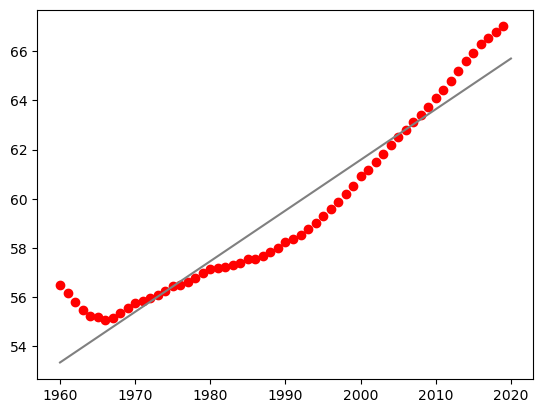

In [46]:
plt.scatter(X,y,color='red',label='Actual Data')
plt.plot(
    X,sc_y.inverse_transform(svr_linear.predict(
            sc_X.transform(X)
    ).reshape(-1,1)
                            ),
    color='grey',
    label='Linear kernal'
)

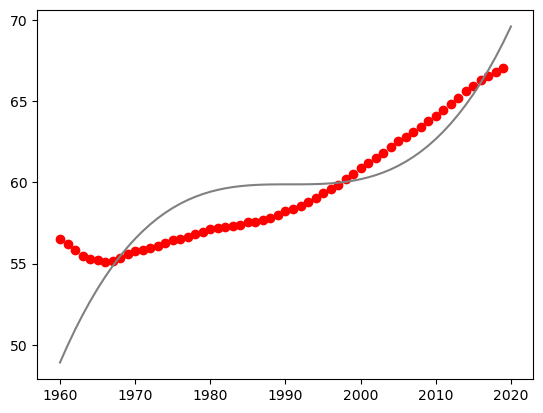

In [47]:
plt.scatter(X,y,color='red',label='Actual Data')
plt.plot(
    X,sc_y.inverse_transform(svr_poly.predict(
            sc_X.transform(X)
    ).reshape(-1,1)
                            ),
    color='grey',
    label='Linear kernal'
)

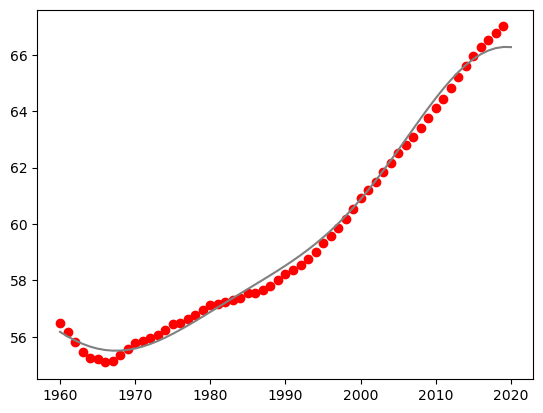

In [48]:
plt.scatter(X,y,color='red',label='Actual Data')
plt.plot(
    X,sc_y.inverse_transform(svr_rbf.predict(
            sc_X.transform(X)
    ).reshape(-1,1)
                            ),
    color='grey',
    label='Linear kernal'
)

### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data). 
Remember: You must transform the input before predicting, and inverse transform the output.

In [49]:
# Predict for Year 2025

year = np.array([[2025]])

# Scale the input
year_scaled = sc_X.transform(year)

# Predict
pred_scaled = svr_rbf.predict(year_scaled)

# Convert back to original scale
pred = sc_y.inverse_transform(pred_scaled.reshape(-1, 1))

print(f"The predicted value for input 2025 is: {pred[0][0]:.2f}")

The predicted value for input 2025 is: 65.62
